In [26]:
# Libraries
import numpy as np
import sympy as sp
import sympy.physics.mechanics as me
import matplotlib.pyplot as plt
from anastruct import SystemElements


In [27]:
def Pin_locator(theta_deg, L, pin_name=None):

    theta = np.radians(theta_deg)
    x   = L * np.cos(theta)  
    y   = L * np.sin(theta)    
    x_h = x / 2                  
    y_h = y / 2                  
    H  = np.array([0.0,L],dtype=float) 
    B  = np.array([x,L],dtype=float)  
    #D  = np.array([2*x,L],dtype=float) 
    A  = np.array([0.0,L - y],dtype=float) 
    C  = np.array([x, L - y],dtype=float)  
    #E  = np.array([2*x,L - y],dtype=float)  
    P1 = np.array([x_h,L - y_h], dtype=float)  
    P2 = np.array([x + x_h,L - y_h], dtype=float)  

    pins_dict = {'H': H, 'A': A, 'P1': P1, 'B': B,'C': C, 'P2': P2}

    if pin_name is None:
        return H, A, P1, B, C, P2
    else:
        if pin_name not in pins_dict:
            raise ValueError(f"Pin '{pin_name}' Error")
        return pins_dict[pin_name]


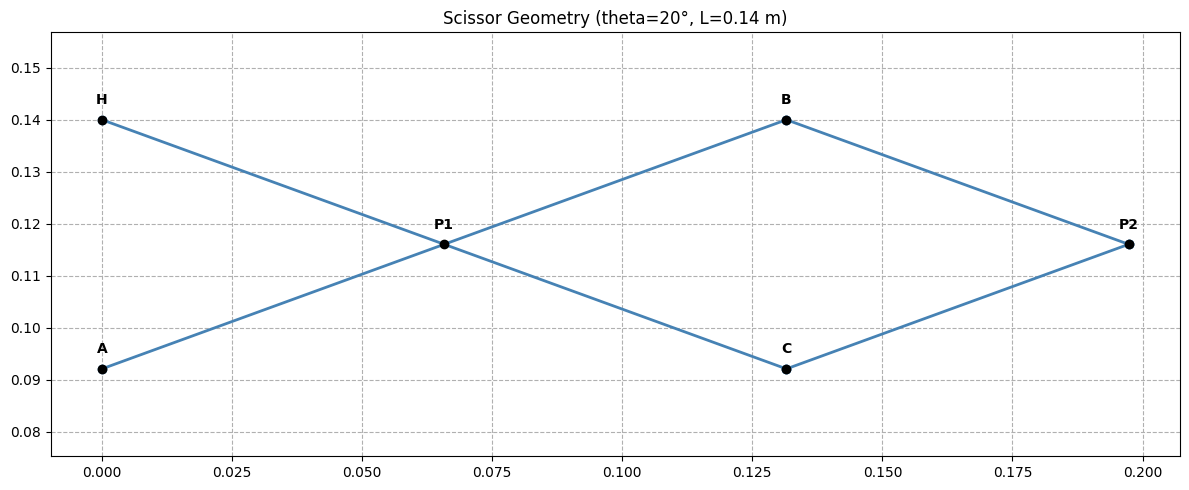

In [28]:
def plot_scissor(theta_deg, L=0.140):

    H, A, P1, B, C, P2 = Pin_locator(theta_deg, L)

    bars = [
        (H, C), (A, B),  
        (B, P2), (C, P2),        
    ]

    plt.figure(figsize=(12, 5))
    for p1, p2 in bars:
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-', color='steelblue', linewidth=2)

    points = {'H': H, 'A': A, 'P1': P1, 'B': B, 'C': C, 'P2': P2}
    for name, pt in points.items():
        plt.text(pt[0], pt[1] + 0.003, name, fontsize=10, fontweight='bold', ha='center')
        plt.plot(pt[0], pt[1], 'ko', markersize=6)

    plt.title(f'Scissor Geometry (theta={theta_deg}°, L={L} m)')
    plt.grid(True, linestyle='--')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_scissor(20, 0.140)


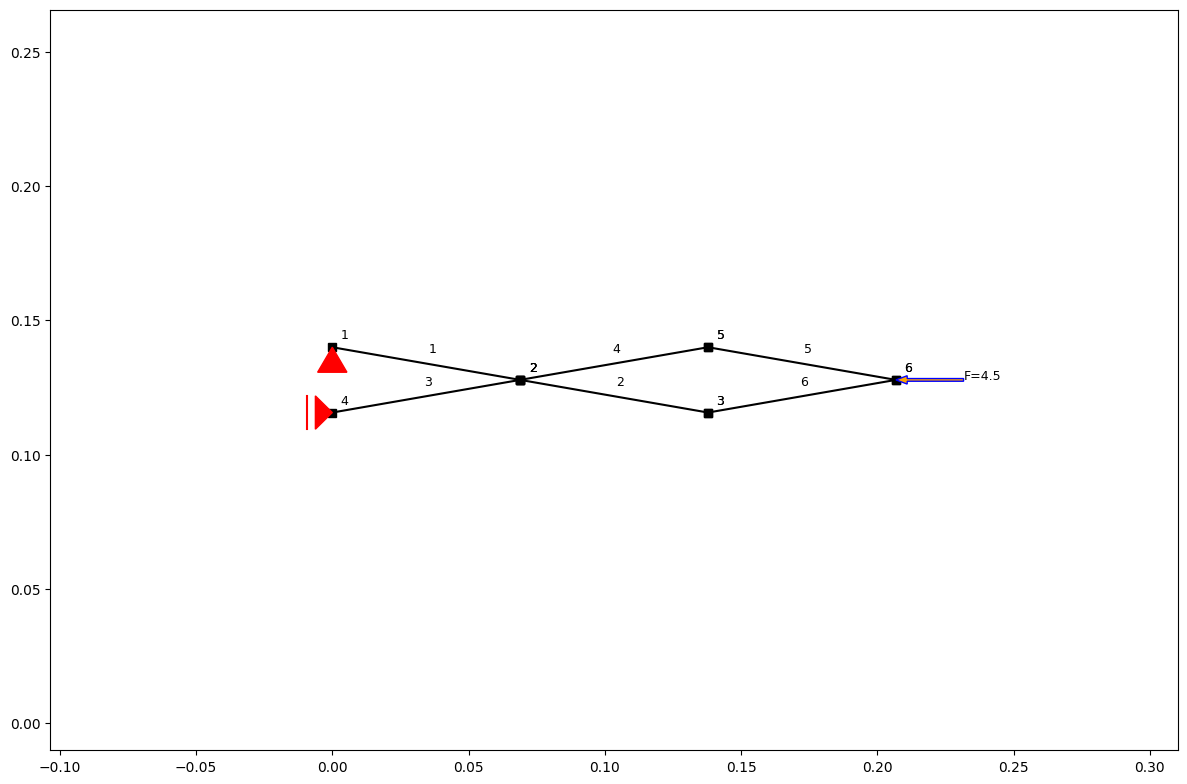

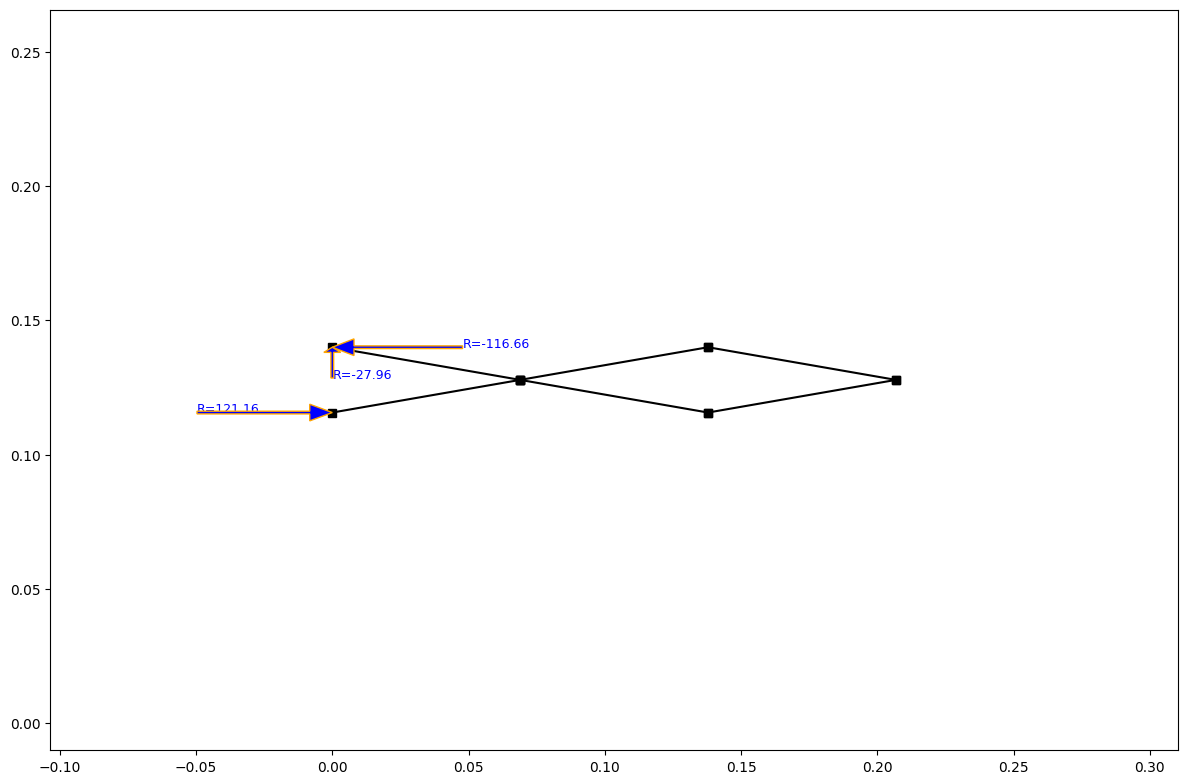

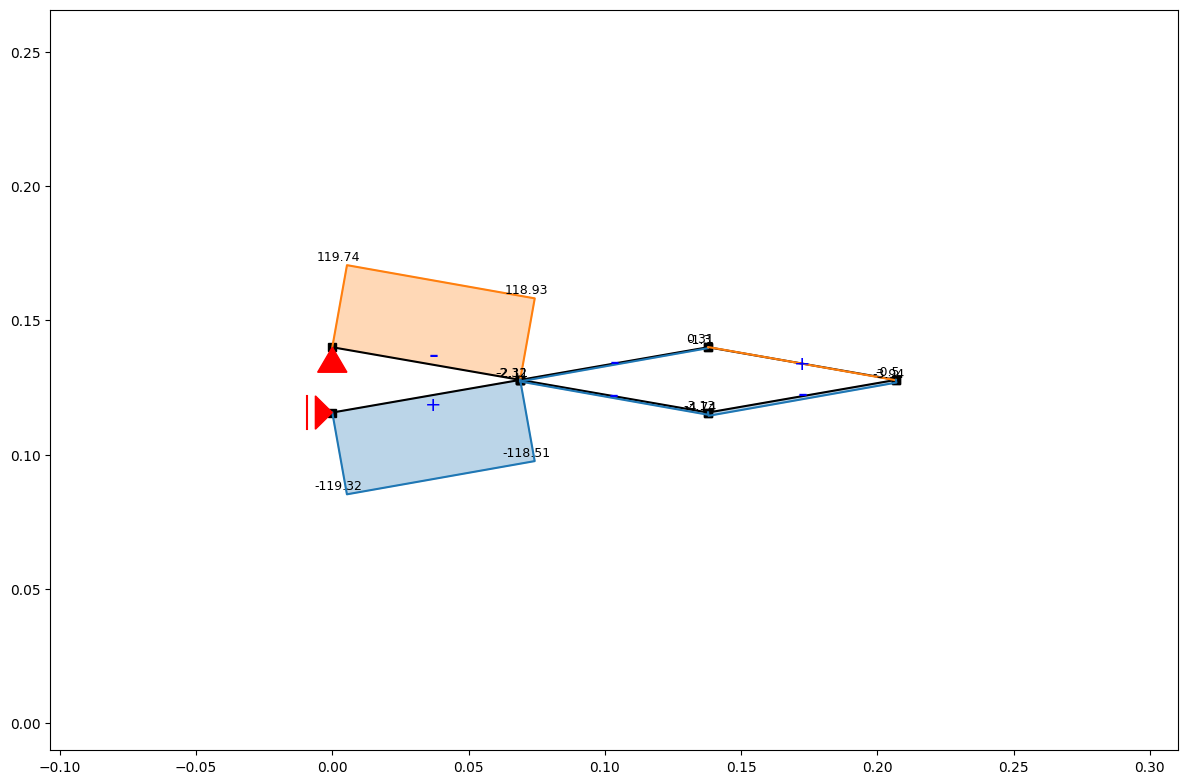

[<Axes: title={'center': 'structure'}>, <Axes: >]


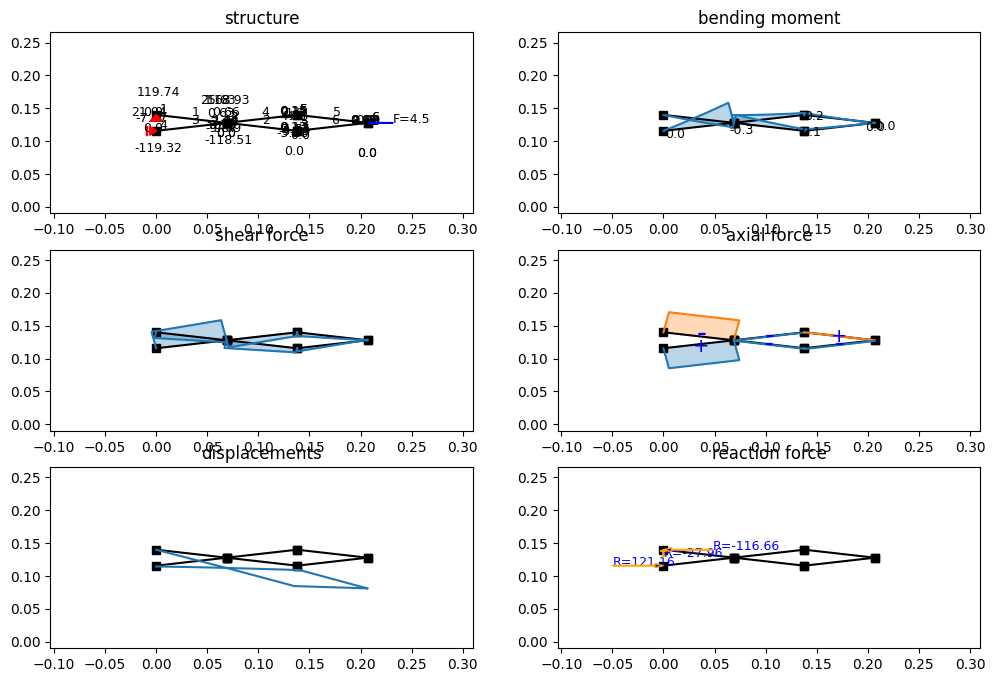

In [31]:
#Materia Px
E_al    = 70e9           # Young's Modulus (Pa)
rho_al  = 2700           # Density (kg/m^3)
A_cs    = 0.002513       # Cross-sectional area (m^2)
I       = 0.00000204204  # Inertia
g       = 9.81           # Gravity (m/s^2)

weight_per_meter = rho_al * A_cs * g  # Self-weight per unit length (N/m)


def truss_forces(theta_deg, L, A_cs, E_al, Px):

    ss = SystemElements(EA=float(E_al * A_cs), EI=float(E_al * I))

    # 1. Coordinates
    pin_names = ['H', 'A', 'P1', 'B', 'C', 'P2']
    coords = {name: Pin_locator(theta_deg, L, pin_name=name) for name in pin_names}

    # 2. Connectivity — elements split at pivots

    elements = [
        ('H', 'P1'), ('P1', 'C'), ('A', 'P1'), ('P1', 'B'),  
        ('B', 'P2'),('C', 'P2')                                  
    ]

    for n1, n2 in elements:
        ss.add_element(
            location=[coords[n1], coords[n2]],
            EA=float(E_al * A_cs),
            EI=float(E_al * I),
            g=float(weight_per_meter)
        )

    # 3. Boundary conditions
    id_P2=ss.find_node_id(coords['P2'])
    id_A=ss.find_node_id(coords['A'])
    id_H=ss.find_node_id(coords['H'])
    ss.add_support_hinged(node_id=id_H)           
    ss.add_support_roll(node_id=id_A, direction='y',angle=270, rotate=True) 


    # 4. Load 
    ss.point_load(id_P2, -Px)
    
    
    ss.solve()

    # 6. Display 
    ss.show_structure()
    ss.show_reaction_force()
    ss.show_axial_force()
    ss.show_results()
    ss.get_element_result_range('axial',minmax='both')

    return ss

system = truss_forces(10, 0.140, A_cs, E_al, Px=4.5)
